# <center>Neural Networks for Raman Spectroscopy

Raman spectroscopy is an extremely useful technique for identifying molecules and crystals, because it is an inexpensive, cheap and non-invasive probe. Indeed, Raman measurements have already become common place in the pharmaceutical industry for identifying the composition of tablets.

This notebook shows how machine learning can be used to identify materials from the 1D Raman spectra. The example data comes from the crystals ReS$_{2}$ and ReSe$_{2}$.

---
### Import Modules

In [4]:
import os
import zipfile
import random
import shutil
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from shutil import copyfile
import matplotlib.pyplot as plt
import keras_tuner as kt
from tensorflow.keras.optimizers import Adam
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns

---
### Create directories and copy in data

The folder structure should be: <br>
project root <br>
| <br>
--this_notebook_file.ipynb <br>
--requirements.txt <br>
--data <br>
>--ReSe2 <br>
>--ReS2 <br>

The name of the subfolders in the data folder are used as labels.

The folder creator will make a folder called "Raman" with training and validation subfolders. This is done so the data is in a structure compatible with TensorFlow generators.
    

In [6]:
def folder_creater(folder, directory, SPLIT_SIZE = 0.8):
    
    parent_dir = os.getcwd()
    path = os.path.join(parent_dir, directory)

    # Empty directory to prevent FileExistsError if the function is run several times
    if os.path.exists(path):
      shutil.rmtree(path)
    
    # Create top directory
    os.makedirs(path)
    path = os.path.join(parent_dir, directory)
    
    # Find name of labels for folder names
    path_images = parent_dir + '/' + folder
    _tmp = os.listdir(path_images)
    _tmp.remove('.DS_Store')
    
    # Create the training and validation subdirectories
    training = os.path.join(path, 'training')
    os.makedirs(training)
    if os.path.exists(os.path.join(training, '.DS_Store')):
        os.remove(os.path.join(training, '.DS_Store'))
        
    validation = os.path.join(path, 'validation')
    os.makedirs(validation)
    if os.path.exists(os.path.join(validation, '.DS_Store')):
        os.remove(os.path.join(validation, '.DS_Store'))

    # Loop over all different labels
    for i in range(len(_tmp)):
        
        # Create subdirectories with name of labels in training
        # and validation folders
        new_train = os.path.join(training, _tmp[i])
        os.makedirs(new_train)
        new_validation = os.path.join(validation, _tmp[i])
        os.makedirs(new_validation)
        
        # Find names of image files
        _sub_folder = os.path.join(path_images, _tmp[i])
        _files = os.listdir(_sub_folder)
        if '.DS_Store' in _files:
            _files.remove('.DS_Store')
        
        # Shuffle the files
        random.sample(_files, len(_files))
        
        # Split into training and validation sets
        _train = _files[:int(SPLIT_SIZE*len(_files))]
        _validation = _files[int(SPLIT_SIZE*len(_files)):]
        
        # Copy files from original folders to new directories that
        # have been created for use with ImageGenerator
        for _file in _train:
            copyfile(_sub_folder + '/' + _file, new_train + '/' + _file)
        for _file in _validation:
            copyfile(_sub_folder + '/' + _file, new_validation + '/' + _file)
        
        # Check that the number of images matches the expected output
        print(f"\n\nThere are {len(os.listdir(new_train))} images of {_tmp[i]} for training")
        print(f"There are {len(os.listdir(new_validation))} images of {_tmp[i]} for validation")
        
    return training, validation

folder="data"
directory = "Raman"

TRAIN_DIR, VALIDATION_DIR = folder_creater(folder,directory)



There are 67 images of ReS2 for training
There are 17 images of ReS2 for validation


There are 72 images of ReSe2 for training
There are 18 images of ReSe2 for validation


In [7]:
# Check the folders have been created succcessfully

parent_dir = os.getcwd()
directory = "Raman"

path = os.path.join(parent_dir, directory)

for rootdir, dirs, files in os.walk(path):
    for subdir in dirs:
        print(os.path.join(rootdir, subdir))

/Users/lewishart/Tensor_flow/Raman/Raman/training
/Users/lewishart/Tensor_flow/Raman/Raman/validation
/Users/lewishart/Tensor_flow/Raman/Raman/training/ReS2
/Users/lewishart/Tensor_flow/Raman/Raman/training/ReSe2
/Users/lewishart/Tensor_flow/Raman/Raman/validation/ReS2
/Users/lewishart/Tensor_flow/Raman/Raman/validation/ReSe2


---
### Display graphs

Below the Raman spectra are diplayed

In [9]:
def Graph_display(crystal, number = 8):
    '''
    A function to visualize the Raman spectra
    Parameters:
        Crystal - Type of material the Raman spectra belongs to
        number - Number of spectra to display
    '''
    # Index for iterating over images
    pic_index = 0

    # Directory containing the data
    dire = os.path.join(parent_dir, 'Raman/training/'+crystal)

    # Filenames
    name = os.listdir(dire)
    names = name[:number]

    # Parameters for our graph; we'll output images in a 4x4 configuration
    nrows = int(len(names)/4) + 1
    ncols = 4

    # Set up matplotlib fig, and size it to fit 4x4 pics
    fig = plt.gcf()
    fig.set_size_inches(ncols * 4, nrows * 4)

    # Create a list of all filenames
    pix = [os.path.join(dire, fname) for fname in names]

    for i, img_path in enumerate(pix):
        # Set up subplot; subplot indices start at 1
        sp = plt.subplot(nrows, ncols, i + 1)
        
        # Load Raman spectra skipping the first row which contains labels
        img = np.loadtxt(img_path, skiprows=1)
        
        # Plot Raman spectra
        plt.plot(img[:,0],img[:,1])
        plt.xlabel('Raman Shift / $cm^{-1}$')
        plt.ylabel('Intensity / arb. units')
        plt.tight_layout()

    plt.show()

# Visualize ReS2 Raman spectra
# Graph_display(crystal='ReS2')

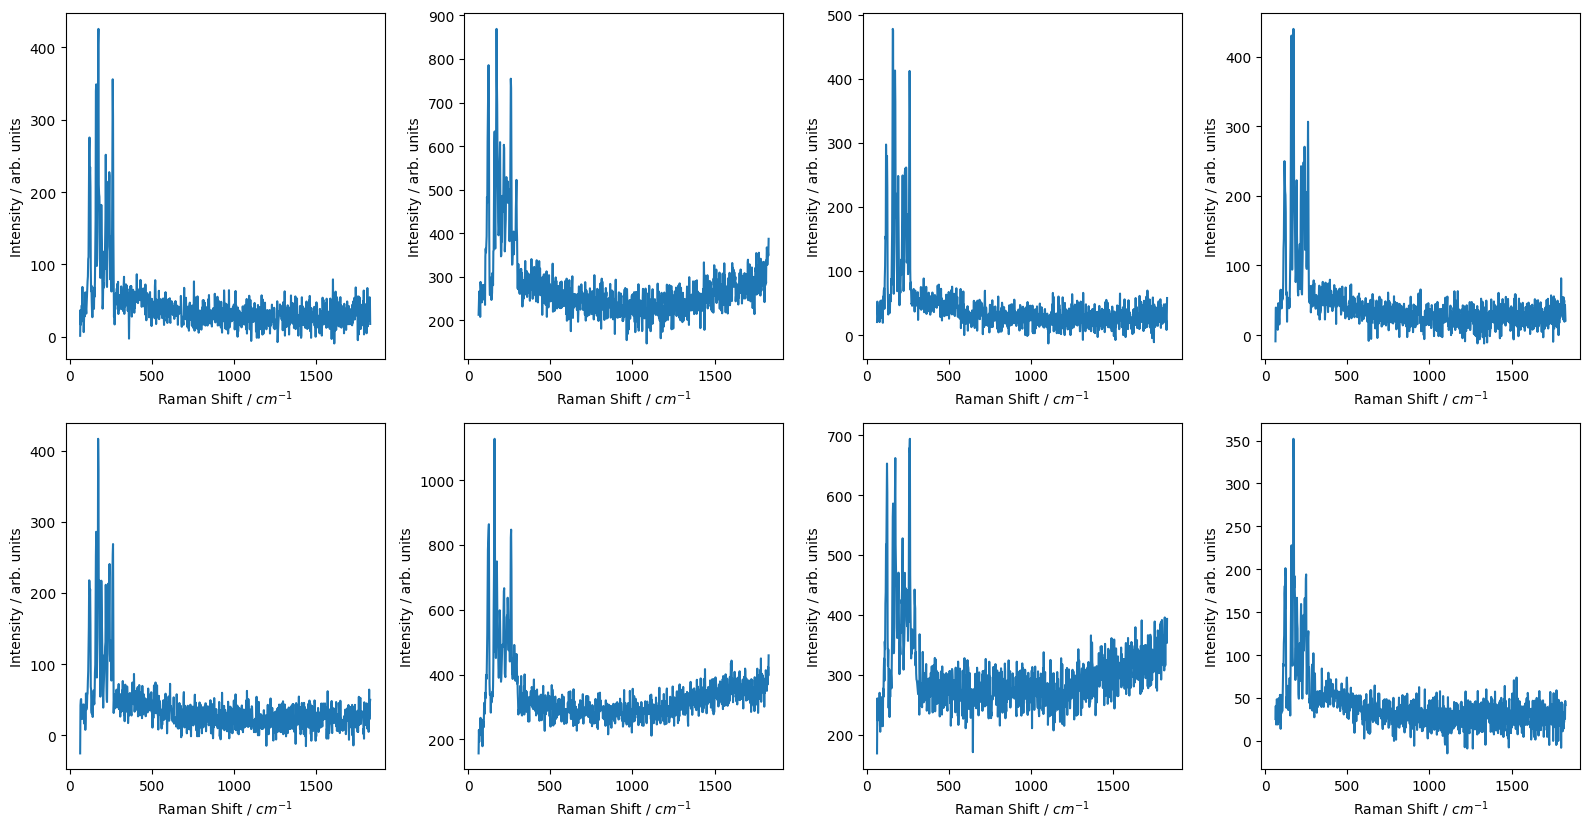

In [10]:
# Visualize ReS2 Raman spectra
Graph_display(crystal='ReSe2')

---
### Create a Data Generator

In [11]:
class DataGenerator(tf.keras.utils.Sequence):
    '''
    Generates data for Keras from the folders structure previously defined
    '''
    def __init__(self, path, batch_size=32, dim=(1000,2), n_channels=1,
                 shuffle=True, training=True):
        # Dimension of the Raman spectra
        self.dim = dim
        
        # Batch size, default = 32
        self.batch_size = batch_size
        
        # Path to the directory containing the Raman spectra
        if training:
            self.path = path + '/training'
        else:
            self.path = path + '/validation'
            
        # Need to read the location of all files and the name of the folder for labels
        # Create containers for filename list, a list of labels
        self.list_IDs = []
        _labels_cont = []
        
        # Identify all labels
        labels = os.listdir(self.path)
        
        # Create a dictionary with keys: labels and an identifying number
        self.labels_dic = dict(zip(labels,range(len(labels))))
        
        for label in labels:
            # folder containing all files of a label
            _file_path = os.path.join(self.path, label)
            
            # All the filenames corresponding to a label
            _file = os.listdir(_file_path)
            
            # Add filenames to a list
            self.list_IDs.extend(_file)
            
            # list that is the length of the number of files all containing the label
            _labels_cont.extend(np.full(len(_file),label))
        
        # Dictionary with keys: filename and label
        self.labels = dict(zip(self.list_IDs,_labels_cont))
        
        # Number of channels
        self.n_channels = n_channels
        
        # Reorder list of files
        self.shuffle = shuffle
        
        self.on_epoch_end()

    def __len__(self):
        'Denotes the number of batches per epoch'
        return int(np.floor(len(self.list_IDs) / self.batch_size))

    def __getitem__(self, index):
        'Generate one batch of data'
        # Generate indexes of the batch
        indexes = self.indexes[index*self.batch_size:(index+1)*self.batch_size]

        # Find list of IDs
        list_IDs_temp = [self.list_IDs[k] for k in indexes]

        # Generate data
        X, y = self.__data_generation(list_IDs_temp)

        return X, y

    def on_epoch_end(self):
        'Updates indexes after each epoch'
        self.indexes = np.arange(len(self.list_IDs))
        if self.shuffle == True:
            np.random.shuffle(self.indexes)

    def __data_generation(self, list_IDs_temp):
        'Generates data containing batch_size samples' # X : (n_samples, *dim, n_channels)
        # Initialization
        X = np.empty((self.batch_size, *self.dim))
        y = np.empty((self.batch_size), dtype=int)

        # Generate data
        for i, ID in enumerate(list_IDs_temp):
            # Store sample
            X[i,] = np.loadtxt(os.path.join(os.path.join(self.path, self.labels[ID]),ID), skiprows=1, max_rows=1000)

            # Normalize spectrum
            X[i,:,1] = (X[i,:,1] - np.min(X[i,:,1])) / (np.max(X[i,:,1]) - np.min(X[i,:,1])+ 1e-8)
            
            # Store label
            y[i] = self.labels_dic[self.labels[ID]]
            
        return X, y #tf.keras.utils.to_categorical(y, num_classes=len(self.labels_dic))
    
# Parameters
params = {'dim': (1000,2),
          'batch_size': 32,
          'n_channels': 1,
          'shuffle': True}

path = os.path.join(parent_dir, 'Raman')

# Generators
training_generator = DataGenerator(path, training=True, **params)
validation_generator = DataGenerator(path, training=False, **params)

---
### Design model & get an idea of a good learning rate

For classification problem of images (2 dimensional data), Conv2D layers are typically used at the start of a model. This project explores how effective Conv1D are for classification of the 1 dimensional data Raman spectra.

The following code explores what a good value for learning rate is, which will later be used when fitting the data in the classification model.

In [13]:
def adjust_learning_rate(dataset):
    
    model = tf.keras.models.Sequential([
        # Input shape is 2 columns - Raman Shift and Intensity,
        # 10000 data points in the Raman spectra
        tf.keras.layers.Input(shape=(1000, 2)),
        tf.keras.layers.Conv1D(16, (3), activation='relu'),
        tf.keras.layers.MaxPooling1D(2),
        tf.keras.layers.Conv1D(32, (3), activation='relu'),
        tf.keras.layers.MaxPooling1D(2), 
        tf.keras.layers.Conv1D(64, (3), activation='relu'), 
        tf.keras.layers.MaxPooling1D(2),
        # Flatten the results to feed into a DNN
        tf.keras.layers.Flatten(), 
        # 512 neuron hidden layer
        tf.keras.layers.Dense(units = 512, activation='relu'), 
        # Only 1 output neuron. It will contain a value from 0-1
        # where 0 for 1 class ('ReS2') and 1 for the other ('ReSe2')
        tf.keras.layers.Dense(1, activation='sigmoid')  
    ])
    
    model.summary()

        
    class LearningRateLogger(tf.keras.callbacks.Callback):
        def on_epoch_end(self, epoch, logs=None):
            logs = logs or {}
            logs['lr'] = self.model.optimizer.learning_rate.numpy()

    
    lr_schedule = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-4 * 10**(epoch / 4))
    lr_logger = LearningRateLogger()
    
    model.compile(optimizer=Adam(),
              loss='binary_crossentropy',
              metrics = ['accuracy'])
    
    history = model.fit(training_generator, epochs=20, verbose=0, callbacks=[lr_schedule, lr_logger])
    
    return history

In [14]:
# Run the training with dynamic LR
lr_history = adjust_learning_rate(training_generator)

2025-10-07 14:38:34.836869: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2025-10-07 14:38:34.836893: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-10-07 14:38:34.836898: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2025-10-07 14:38:34.836913: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-10-07 14:38:34.836920: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 998, 16)        │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 499, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 497, 32)        │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 248, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 246, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 123, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7872)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,030,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,039,377 (15.41 MB)

 Trainable params: 4,039,377 (15.41 MB)

 Non-trainable params: 0 (0.00 B)

/Users/lewishart/.local/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
2025-10-07 14:38:35.278178: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


Text(0.5, 1.0, 'Exploring learning rate for classification of Raman spectra')

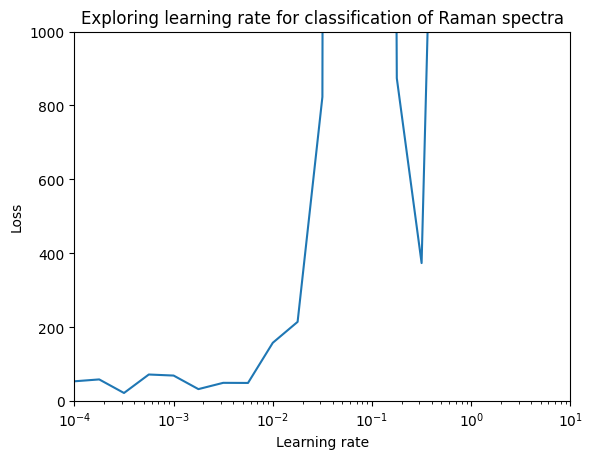

In [15]:
plt.semilogx(lr_history.history["lr"], lr_history.history["loss"])
plt.axis([1e-4, 10, 0, 1000])
plt.xlabel('Learning rate')
plt.ylabel('Loss')
plt.title('Exploring learning rate for classification of Raman spectra')

---
### Vary parameters to find best model

The number of dropout units is varied to identify the best model that limits overfitting.

In [17]:
def model_builder(hp):

    hp_units = hp.Float('units', min_value=0.0, max_value=0.6, step=0.1)
    
    model = tf.keras.models.Sequential([
        tf.keras.layers.Conv1D(16, (3), activation='relu', input_shape=(1000,2)),
        tf.keras.layers.MaxPooling1D(2),
        tf.keras.layers.Conv1D(32, (3), activation='relu'),
        tf.keras.layers.MaxPooling1D(2), 
        tf.keras.layers.Conv1D(64, (3), activation='relu'), 
        tf.keras.layers.MaxPooling1D(2),
        # Flatten the results to feed into a DNN
        tf.keras.layers.Flatten(), 
        # 512 neuron hidden layer
        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.Dropout(hp_units),
        # Only 1 output neuron. It will contain a value from 0-1 where 0 for 1 class ('cats') and 1 for the other ('dogs')
        tf.keras.layers.Dense(1, activation='sigmoid')  
    ])
    
    # Tune the learning rate for the optimizer
    # Choose an optimal value from 0.01, 0.001, or 0.0001
    #hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    
    model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics = ['accuracy'])
    
    return(model)

tuner = kt.RandomSearch(model_builder,
                     objective='val_accuracy',
                     directory='my_dir4',
                     project_name='Raman',
                       overwrite=True)

#Stop the training if the validation loss does not improve after epochs
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=20)
tensor_board = tf.keras.callbacks.TensorBoard()

tuner.search(training_generator, epochs=100, validation_data = validation_generator, callbacks=[stop_early, tensor_board])

# Get the optimal hyperparameters
best_hps=tuner.get_best_hyperparameters(num_trials=1)[0]

Trial 6 Complete [00h 00m 05s]
val_accuracy: 0.59375

Best val_accuracy So Far: 0.59375
Total elapsed time: 00h 00m 47s


In [18]:
print(f"""
The hyperparameter search is complete.\nThe optimal number of dropout units in the first densely-connected layer is {best_hps.get('units')}.
""")


The hyperparameter search is complete.
The optimal number of dropout units in the first densely-connected layer is 0.30000000000000004.



---
### Build the model using the best parameters found earlier

In [20]:
# Build the model with the optimal hyperparameters and train it on the data for 50 epochs
model = tuner.hypermodel.build(best_hps)

model_weights = os.path.join(os.getcwd(), 'model_weights')

# Empty directory to prevent FileExistsError is the function is run several times
if os.path.exists(model_weights):
    shutil.rmtree(model_weights)

os.makedirs(model_weights)

model_weights = os.path.join(os.getcwd(), 'model_weights', 'best_model.weights.h5')

# Create a callback that saves the model's weights
cp_callback = tf.keras.callbacks.ModelCheckpoint(filepath=model_weights,
                                                 save_weights_only=True,
                                                 save_best_only=True,
                                                 verbose=0)

history = model.fit(
            training_generator,
            epochs=800,
            validation_data=validation_generator,
            verbose=0,
            callbacks=[cp_callback]
            )

---
### Visualize accuracy and loss as a function of epoch

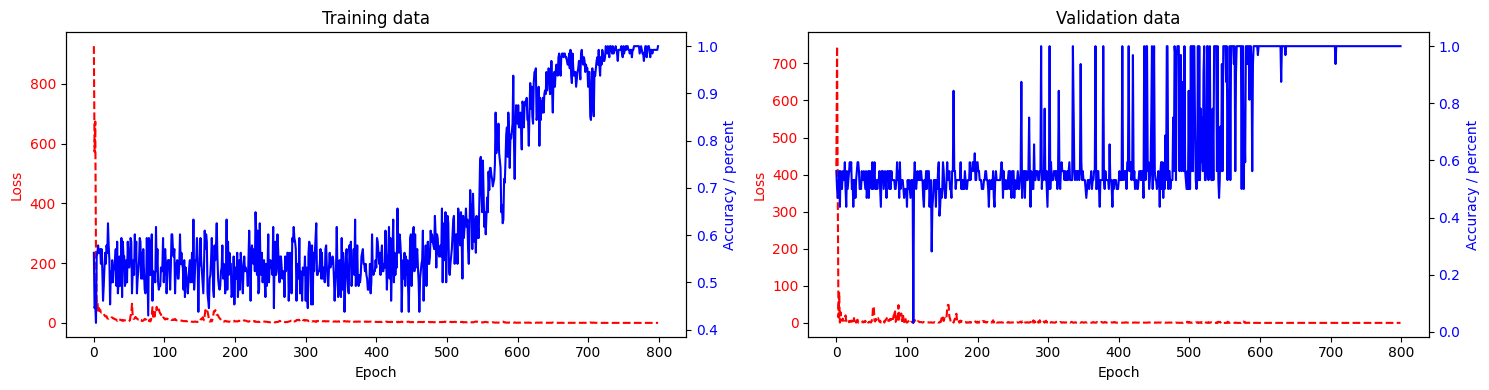

In [22]:
#-----------------------------------------------------------
# Retrieve a list of list results on training and test data
# sets for each training epoch
#-----------------------------------------------------------
acc=history.history['accuracy']
val_acc=history.history['val_accuracy']
loss=history.history['loss']
val_loss=history.history['val_loss']

epochs=range(len(acc)) # Get number of epochs

# Visualize loss  and accuracy history
fig, ax = plt.subplots(nrows=1,ncols=2, figsize=(15,4))
ax2 = ax[0].twinx()
ax[0].plot(history.history['loss'], 'r--',)
ax2.plot(history.history['accuracy'], 'b-')
ax[0].set_xlabel('Epoch')
ax[0].tick_params(axis='y', labelcolor='r')
ax2.set_ylabel('Accuracy / percent',c='b')
ax[0].set_ylabel('Loss', c='r')
ax2.tick_params(axis='y', labelcolor='b')
ax[0].set_title('Training data')

ax3 = ax[1].twinx()
ax[1].plot(history.history['val_loss'], 'r--',)
ax3.plot(history.history['val_accuracy'], 'b-')
ax[1].set_xlabel('Epoch')
ax[1].tick_params(axis='y', labelcolor='r')
ax3.tick_params(axis='y', labelcolor='b')
ax3.set_ylabel('Accuracy / percent',c='b')
ax[1].set_ylabel('Loss', c='r')
ax[1].set_title('Validation data')
plt.tight_layout()

---
### Evaluate the model

In [24]:
# Create a basic model instance
model_best = tuner.hypermodel.build(best_hps)

# Loads the weights
model_best.load_weights(model_weights)

# Evaluate the model
loss, acc = model_best.evaluate(validation_generator, verbose=2)
print("Trained model, accuracy: {:5.2f}%".format(100 * acc))

1/1 - 0s - 174ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Trained model, accuracy: 100.00%


/Users/lewishart/.local/lib/python3.9/site-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


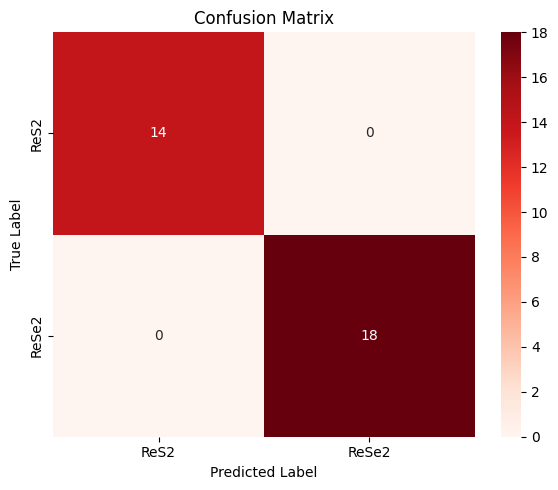

In [25]:
# Collect predictions and true labels
y_true = []
y_pred = []
y_prob = []

for X_batch, y_batch in validation_generator:
    preds = model_best.predict(X_batch)
    y_true.extend(y_batch)
    y_pred.extend((preds > 0.5).astype(int).flatten())
    y_prob.extend(preds.flatten())
    if len(y_true) >= len(validation_generator) * validation_generator.batch_size:
        break

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['ReS2', 'ReSe2'], yticklabels=['ReS2', 'ReSe2'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()

Classification Report:
              precision    recall  f1-score   support

        ReS2       1.00      1.00      1.00        14
       ReSe2       1.00      1.00      1.00        18

    accuracy                           1.00        32
   macro avg       1.00      1.00      1.00        32
weighted avg       1.00      1.00      1.00        32



<function matplotlib.pyplot.show(close=None, block=None)>

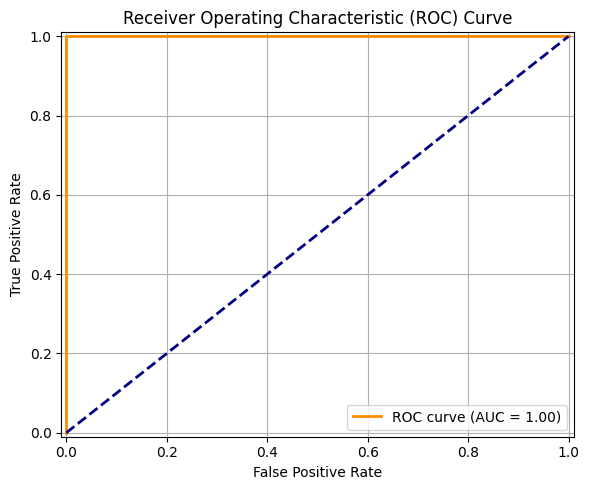

In [26]:
# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=['ReS2', 'ReSe2']))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show

---
### Test the model

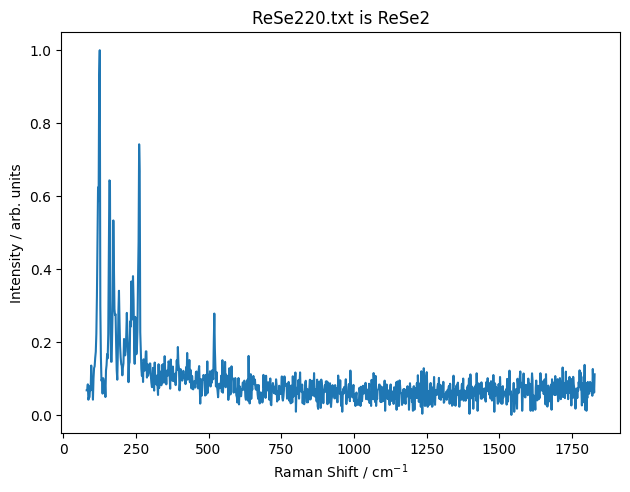

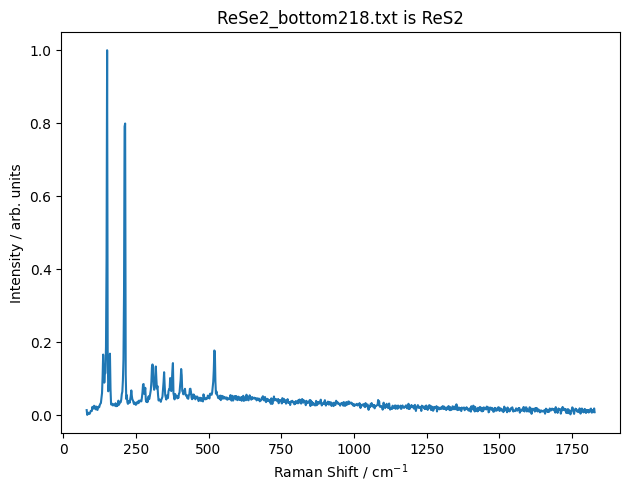

In [28]:
test_dir = os.path.join(os.getcwd(), 'test_images')
test_files = os.listdir(test_dir)
test_files.remove('.DS_Store')

for fn in test_files:
    # predicting images
    t = test_dir + '/' + fn
    spec=np.loadtxt(t, skiprows=1, max_rows=1000)
    
    # Normalize intensity (column 1)
    intensity = spec[:, 1]
    intensity_norm = (intensity - np.min(intensity)) / (np.max(intensity) - np.min(intensity) + 1e-8)
    spec[:, 1] = intensity_norm


    x=np.expand_dims(spec, axis=0)
    spectra = np.vstack([x])

    classes = model_best.predict(spectra, batch_size=1, verbose=3)
    plt.figure()
    plt.plot(spec[:,0],spec[:,1])
    plt.xlabel('Raman Shift / cm$^{-1}$')
    plt.ylabel('Intensity / arb. units')
    plt.tight_layout()

    if classes[0]>0.5:
        plt.title(fn + " is ReSe2")
    else:
        plt.title(fn + " is ReS2")

### Conclusions

This model is able to determine whether Raman spectra belongs to ReS$_{2}$ or ReSe$_{2}$, even when other compounds are measured at the same time. The next steps will be to expand this a multiclass problem where multiple compounds can be identified. This model can be significantly improved with more data.